# Part 1: Building Large Language Model (LLM) from Scratch

## Part 1.1 — Data Preprocessing

In [1]:
#Install Required libraries
!pip -q install datasets tqdm

In [2]:
#Import Libraries
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader

In [3]:
#Set seeds for reproducibility and select the GPU as the device, the code will use
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
#Defining Hyperparameters
train_data_count = 100000
val_data_count = 10000

context_length = 128
batch_size = 64
embedding_dim = 192
num_heads = 4
num_layers = 4
dropout = 0.1

learning_rate = 3e-4
weight_decay = 1e-2
epochs = 10
warmup_steps = 500

# fixed-length chunks from the 100K/10K story splits each epoch while training
train_samples_per_epoch = 12000
val_samples_per_epoch = 2000

generate_max_new_tokens = 300

In [5]:
#Load the TinyStories dataset and only take 110K stories from the dataset
dataset = load_dataset("roneneldan/TinyStories", split=f"train[:{train_data_count + val_data_count}]")
print(dataset)
print("Total loaded stories:", len(dataset))
print("\nExample story:\n")
print(dataset[0]["text"][:500])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Dataset({
    features: ['text'],
    num_rows: 110000
})
Total loaded stories: 110000

Example story:

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them b


In [6]:
#Split dataset into train and validation
train_texts = [dataset[i]["text"] for i in range(train_data_count)]
val_texts = [dataset[i]["text"] for i in range(train_data_count, train_data_count + val_data_count)]

print("Training stories:", len(train_texts))
print("Validation stories:", len(val_texts))

Training stories: 100000
Validation stories: 10000


In [7]:
#Character-level tokenization (means every unique character gets an integer id)
#Add a special character between stories to let model know story separation
separator_char = "|"

all_text_for_vocab = separator_char.join(train_texts + val_texts)

chars = sorted(list(set(all_text_for_vocab)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

print("Vocabulary size:", vocab_size)
print("First 50 characters in vocab:")
print(chars[:50])

Vocabulary size: 111
First 50 characters in vocab:
['\t', '\n', ' ', '!', '"', '#', '$', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']


In [8]:
#Convert character to integers
def encode(text):
    return [char_to_idx[ch] for ch in text]

def decode(indices):
    return "".join(idx_to_char[i] for i in indices)

train_joined = separator_char.join(train_texts)
val_joined = separator_char.join(val_texts)

train_data = torch.tensor(encode(train_joined), dtype=torch.long)
val_data = torch.tensor(encode(val_joined), dtype=torch.long)

print("Train token count:", len(train_data))
print("Val token count:", len(val_data))
print("\nDecoded sample check:")
print(decode(train_data[:200].tolist()))

Train token count: 88406739
Val token count: 9066149

Decoded sample check:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on


In [9]:
#Create dataset for random fixed-length chunks
class RandomChunkDataset(Dataset):
    def __init__(self, data_tensor, context_length, samples_per_epoch):
        self.data = data_tensor
        self.context_length = context_length
        self.samples_per_epoch = samples_per_epoch

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, idx):
        start = random.randint(0, len(self.data) - self.context_length - 2)
        x = self.data[start : start + self.context_length]
        y = self.data[start + 1 : start + self.context_length + 1]
        return x, y

train_dataset = RandomChunkDataset(train_data, context_length, train_samples_per_epoch)
val_dataset = RandomChunkDataset(val_data, context_length, val_samples_per_epoch)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

xb, yb = next(iter(train_loader))
print("Input batch shape :", xb.shape)
print("Target batch shape:", yb.shape)

Input batch shape : torch.Size([64, 128])
Target batch shape: torch.Size([64, 128])


## Part 1.2 — GPT Model Implementation

In [10]:
#Layer Normalization
class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        # x shape: (batch, time, channels)
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

In [11]:
#Single self-attention head
class Head(nn.Module):
    def __init__(self, embedding_dim, head_size, context_length, dropout):
        super().__init__()
        self.key = nn.Linear(embedding_dim, head_size, bias=False)
        self.query = nn.Linear(embedding_dim, head_size, bias=False)
        self.value = nn.Linear(embedding_dim, head_size, bias=False)

        # This lower-triangular mask is used for causal masking.
        # A token can only attend to itself and earlier tokens.
        self.register_buffer("tril", torch.tril(torch.ones(context_length, context_length)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        k = self.key(x)
        q = self.query(x)

        # attention scores: (B, T, T)
        scores = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)

        # causal mask: block access to future tokens
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        v = self.value(x)

        out = weights @ v
        return out

In [12]:
#Multi-head self attention
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim, num_heads, context_length, dropout):
        super().__init__()
        head_size = embedding_dim // num_heads
        self.heads = nn.ModuleList([
            Head(embedding_dim, head_size, context_length, dropout)
            for _ in range(num_heads)
        ])
        self.proj = nn.Linear(embedding_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([head(x) for head in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)
        return out

In [13]:
#Feed-forward Network
class FeedForward(nn.Module):
    def __init__(self, embedding_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            nn.GELU(),
            nn.Linear(4 * embedding_dim, embedding_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
#Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads, context_length, dropout):
        super().__init__()
        self.ln1 = LayerNorm(embedding_dim)
        self.attn = MultiHeadAttention(embedding_dim, num_heads, context_length, dropout)
        self.ln2 = LayerNorm(embedding_dim)
        self.ffwd = FeedForward(embedding_dim, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # residual connection
        x = x + self.ffwd(self.ln2(x))   # residual connection
        return x

In [15]:
#GPT model
class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_length, num_heads, num_layers, dropout):
        super().__init__()
        self.context_length = context_length

        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)
        self.position_embedding_table = nn.Embedding(context_length, embedding_dim)

        self.blocks = nn.Sequential(*[
            TransformerBlock(embedding_dim, num_heads, context_length, dropout)
            for _ in range(num_layers)
        ])

        self.ln_f = LayerNorm(embedding_dim)
        self.lm_head = nn.Linear(embedding_dim, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        token_emb = self.token_embedding_table(idx)  # (B, T, C)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding_table(pos) # (T, C)

        x = token_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            B, T, V = logits.shape
            logits_flat = logits.view(B * T, V)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, greedy=False):
        # idx shape: (B, current_length)
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.context_length:]  # keep only the last context_length tokens
            logits, _ = self(idx_cond)

            # take logits from the last time step
            logits = logits[:, -1, :]
            if greedy:
                next_token = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                logits = logits / temperature
                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, next_token), dim=1)

        return idx

In [16]:
#Create the model
model = GPTLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    context_length=context_length,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")

GPTLanguageModel(
  (token_embedding_table): Embedding(111, 192)
  (position_embedding_table): Embedding(128, 192)
  (blocks): Sequential(
    (0): TransformerBlock(
      (ln1): LayerNorm()
      (attn): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=192, out_features=48, bias=False)
            (query): Linear(in_features=192, out_features=48, bias=False)
            (value): Linear(in_features=192, out_features=48, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm()
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=768, out_features=192, bias=True)
          (3): Dropout(p=0.1, inplace=False

## Part 1.3 — Training and Text Generation

In [17]:
#Optimizer and learning rate schedule
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

total_training_steps = epochs * len(train_loader)

def lr_lambda(current_step):
    # Warm-up phase
    if current_step < warmup_steps:
        return float(current_step + 1) / float(max(1, warmup_steps))

    # Cosine decay phase
    progress = float(current_step - warmup_steps) / float(max(1, total_training_steps - warmup_steps))
    progress = min(progress, 1.0)
    return 0.1 + 0.9 * 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

In [18]:
#Training and Evaluation
def train(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for xb, yb in progress_bar:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        _, loss = model(xb, yb)
        loss.backward()

        # Gradient clipping helps training remain stable
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.6f}")

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        _, loss = model(xb, yb)
        total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
#Training Loop
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = "/content/drive/MyDrive/DATA266/Labs/Lab1/Part1/best_gpt_tinystories.pth"

global_start_time = time.time()

for epoch in range(1, epochs + 1):
    print(f"\nEpoch {epoch}/{epochs}")

    train_loss = train(model, train_loader, optimizer, scheduler, device)
    val_loss = evaluate(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")


Epoch 1/10


Training:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 1.4743
Val Loss  : 1.3962
Best model saved.

Epoch 2/10


Training:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 1.4676
Val Loss  : 1.3772
Best model saved.

Epoch 3/10


...

Train Loss: 1.4235
Val Loss  : 1.3405
Best model saved.

Epoch 9/10


Training:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 1.4149
Val Loss  : 1.3298
Best model saved.

Epoch 10/10


Training:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 1.4112
Val Loss  : 1.3339


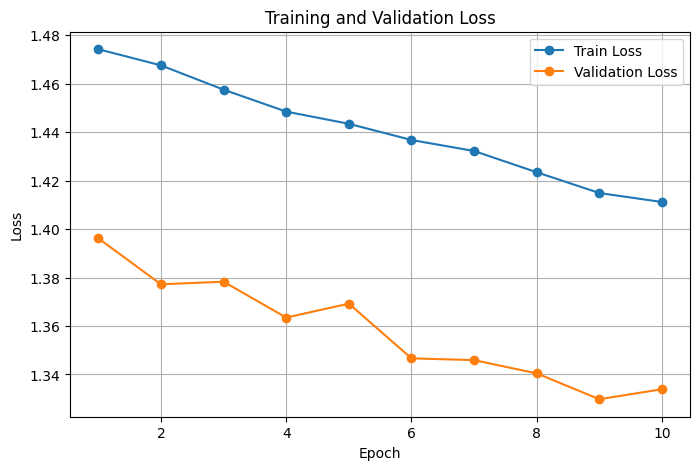

In [21]:
#Training and Validation loss Plots
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, epochs + 1), val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
#Load the best model
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("Best model loaded.")

Best model loaded.


In [23]:
#Create a text generation function
def generate_text(
    prompt=None,
    max_new_tokens=200,
    temperature=1.0,
    greedy=False
):

    # If no prompt is provided, start with an empty string
    if prompt is None:
        prompt = ""

    # Convert prompt text to token ids
    start_ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    # Generate tokens using the trained model
    generated_ids = model.generate(
        idx=start_ids,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        greedy=greedy
    )

    # Convert token ids back to text
    generated_text = decode(generated_ids[0].tolist())

    return generated_text

In [24]:
# Greedy decoding example

text = generate_text(
    prompt="Once upon a time",
    max_new_tokens=300,
    greedy=True
)

print(text)

Once upon a time, there was so happy and said, "I was so happy and said, "I was so happy and said, "I was so happy and said, "I wanted to to to the careful of the started to the started to the started to the started to the started to the started to the started to the started to the started to the started to the sta


In [25]:
# Temperature sampling example

text = generate_text(
    prompt="A little girl named Mia",
    max_new_tokens=300,
    temperature=0.9
)

print(text)

A little girl named Mia open. Suddenly saw toye the rest to cand and such a finifung and didn't wain.

John the slick inside to up, the special maake. He expent would at so pleet with his could. One day, Lily skeet chiminue showed but feel the somer. "You sure always from the fas of atside. When the for very roble her of 


In [28]:
#Multiple examples to analyze failure cases in the generated text
samples = [
    {
        "prompt": "Once upon a time",
        "max_new_tokens": 200,
        "temperature": 1.0,
        "greedy": True
    },
    {
        "prompt": "A little girl named Mia",
        "max_new_tokens": 250,
        "temperature": 0.8,
        "greedy": False
    },
    {
        "prompt": "In a small village",
        "max_new_tokens": 250,
        "temperature": 1.2,
        "greedy": False
    },
    {
        "prompt": "There was a curious cat",
        "max_new_tokens": 300,
        "temperature": 0.9,
        "greedy": False
    }
]

for i, params in enumerate(samples, start=1):

    print("=" * 80)
    print(f"Sample {i}")
    print(f"Prompt: {params['prompt']}")
    print(f"Parameters -> max_new_tokens={params['max_new_tokens']}, "
          f"temperature={params['temperature']}, greedy={params['greedy']}")
    print()

    generated_text = generate_text(
        prompt=params["prompt"],
        max_new_tokens=params["max_new_tokens"],
        temperature=params["temperature"],
        greedy=params["greedy"]
    )

    print(generated_text)
    print("\n")

Sample 1
Prompt: Once upon a time
Parameters -> max_new_tokens=200, temperature=1.0, greedy=True

Once upon a time, there was so happy and said, "I was so happy and said, "I was so happy and said, "I was so happy and said, "I wanted to to to the careful of the started to the started to the started to the started 


Sample 2
Prompt: A little girl named Mia
Parameters -> max_new_tokens=250, temperature=0.8, greedy=False

A little girl named Mia little bird what was and she cared and saw and Lily the car flew and his fill of cat. He was very said not loved to more. One day, a was chan his is a little girl ward was found explorrowith and eved to the treast. She lived to peone shelp bed of th


Sample 3
Prompt: In a small village
Parameters -> max_new_tokens=250, temperature=1.2, greedy=False

In a small village.

No, is mommy to stoding him smiled partle girl and yark, sad pranc!" Lily said," Jucy loving loved tioes, to sight it was s4e it know. 

He mom was snad so verywho rup. Hell what 